# Long-Short Strategy, Part 3: Evaluating our Boosting Model Signals

In this section, we'll start designing, implementing, and evaluating a trading strategy for US equities driven by daily return forecasts produced by gradient boosting models.

As in the previous examples, we'll lay out a framework and build a specific example that you can adapt to run your own experiments. There are numerous aspects that you can vary, from the asset class and investment universe to more granular aspects like the features, holding period, or trading rules. See, for example, the **Alpha Factor Library** in the [Appendix](../24_alpha_factor_library) for numerous additional features.

We'll keep the trading strategy simple and only use a single ML signal; a real-life application will likely use multiple signals from different sources, such as complementary ML models trained on different datasets or with different lookahead or lookback periods. It would also use sophisticated risk management, from simple stop-loss to value-at-risk analysis.

**Six notebooks** cover our workflow sequence:

1. [preparing_the_model_data](04_preparing_the_model_data.ipyny): we engineer a few simple features from the Quandl Wiki data 
2. [trading_signals_with_lightgbm_and_catboost](05_trading_signals_with_lightgbm_and_catboost.ipynb): we tune hyperparameters for LightGBM and CatBoost to select a model, using 2015/16 as our validation period. 
3. `evaluate_trading_signals` (this noteboook): we compare the cross-validation performance using various metrics to select the best model. 
4. [model_interpretation](07_model_interpretation.ipynb): we take a closer look at the drivers behind the best model's predictions.
5. [making_out_of_sample_predictions](08_making_out_of_sample_predictions.ipynb): we generate predictions for our out-of-sample test period 2017.
6. [backtesting_with_zipline](09_backtesting_with_zipline.ipynb): evaluate the historical performance of a long-short strategy based on our predictive signals using Zipline.

Cross-validation of numerous configurations has produced a large number of results. Now, we need to evaluate the predictive performance to identify the model that generates the most reliable and profitable signals for our prospective trading strategy.

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from time import time
from io import StringIO
import sys, os
import warnings
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from scipy.stats import spearmanr, pearsonr

from alphalens import plotting
from alphalens import performance as perf
from alphalens.utils import (
    get_clean_factor_and_forward_returns,
    rate_of_return,
    std_conversion,
)
from alphalens.tears import create_summary_tear_sheet, create_full_tear_sheet

In [3]:
sys.path.append(os.path.dirname(os.getcwd()))
from utils import MultipleTimeSeriesCV

In [4]:
sns.set_style("whitegrid")

In [5]:
YEAR = 252
idx = pd.IndexSlice

In [6]:
scope_params = ["lookahead", "train_length", "test_length"]
daily_ic_metrics = [
    "daily_ic_mean",
    "daily_ic_mean_n",
    "daily_ic_median",
    "daily_ic_median_n",
]
lgb_train_params = [
    "learning_rate",
    "num_leaves",
    "feature_fraction",
    "min_data_in_leaf",
]
catboost_train_params = ["max_depth", "min_child_samples"]

In [7]:
results_path = Path("results", "us_stocks")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Collect Data

We produced a larger number of LightGBM models because it runs an order of magnitude faster than CatBoost and will demonstrate some evaluation strategies accordingly.

### LightGBM

#### Summary Metrics by Fold

First, we collect the summary metrics computed for each fold and hyperparameter combination:

In [8]:
with pd.HDFStore(results_path / "tuning_lgb.h5") as store:
    for i, key in enumerate(
        [k[1:] for k in store.keys() if k[1:].startswith("metrics")]
    ):
        _, t, train_length, test_length = key.split("/")[:4]
        attrs = {
            "lookahead": t,
            "train_length": train_length,
            "test_length": test_length,
        }
        s = store[key].to_dict()
        s.update(attrs)
        if i == 0:
            lgb_metrics = pd.Series(s).to_frame(i)
        else:
            lgb_metrics[i] = pd.Series(s)

id_vars = scope_params + lgb_train_params + daily_ic_metrics
lgb_metrics = (
    pd.melt(
        lgb_metrics.T.drop("t", axis=1),
        id_vars=id_vars,
        value_name="ic",
        var_name="boost_rounds",
    )
    .dropna()
    .apply(pd.to_numeric)
)

In [9]:
lgb_metrics.to_hdf("data/model_tuning.h5", "lgb/metrics")
lgb_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lookahead          4212 non-null   int64  
 1   train_length       4212 non-null   int64  
 2   test_length        4212 non-null   int64  
 3   learning_rate      4212 non-null   float64
 4   num_leaves         4212 non-null   float64
 5   feature_fraction   4212 non-null   float64
 6   min_data_in_leaf   4212 non-null   float64
 7   daily_ic_mean      4212 non-null   float64
 8   daily_ic_mean_n    4212 non-null   float64
 9   daily_ic_median    4212 non-null   float64
 10  daily_ic_median_n  4212 non-null   float64
 11  boost_rounds       4212 non-null   int64  
 12  ic                 4212 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 427.9 KB


In [10]:
lgb_metrics.groupby(scope_params).size()

lookahead  train_length  test_length
1          252           63             702
           1134          63             702
5          252           63             702
           1134          63             702
21         252           63             702
           1134          63             702
dtype: int64

#### Information Coefficient by Day

Next, we retrieve the IC per day computed during cross-validation:

In [11]:
int_cols = ["lookahead", "train_length", "test_length", "boost_rounds"]

In [12]:
lgb_ic = []
with pd.HDFStore(results_path / "tuning_lgb.h5") as store:
    keys = [k[1:] for k in store.keys()]
    for key in keys:
        _, t, train_length, test_length = key.split("/")[:4]
        if key.startswith("daily_ic"):
            df = (
                store[key]
                .drop(["boosting", "objective", "verbose"], axis=1)
                .assign(lookahead=t, train_length=train_length, test_length=test_length)
            )
            lgb_ic.append(df)
    lgb_ic = pd.concat(lgb_ic).reset_index()

In [13]:
id_vars = ["date"] + scope_params + lgb_train_params
lgb_ic = pd.melt(
    lgb_ic, id_vars=id_vars, value_name="ic", var_name="boost_rounds"
).dropna()
lgb_ic.loc[:, int_cols] = lgb_ic.loc[:, int_cols].astype(int)

In [15]:
lgb_ic.to_hdf("data/model_tuning.h5", "lgb/ic")
lgb_ic.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2115448 entries, 0 to 2122847
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   date              2115448 non-null  datetime64[ns]
 1   lookahead         2115448 non-null  object        
 2   train_length      2115448 non-null  object        
 3   test_length       2115448 non-null  object        
 4   learning_rate     2115448 non-null  float64       
 5   num_leaves        2115448 non-null  int64         
 6   feature_fraction  2115448 non-null  float64       
 7   min_data_in_leaf  2115448 non-null  int64         
 8   boost_rounds      2115448 non-null  object        
 9   ic                2115448 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 177.5+ MB


In [16]:
lgb_daily_ic = (
    lgb_ic.groupby(id_vars[1:] + ["boost_rounds"])
    .ic.mean()
    .to_frame("ic")
    .reset_index()
)
lgb_daily_ic.to_hdf("data/model_tuning.h5", "lgb/daily_ic")
lgb_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   lookahead         4212 non-null   int64  
 1   train_length      4212 non-null   int64  
 2   test_length       4212 non-null   int64  
 3   learning_rate     4212 non-null   float64
 4   num_leaves        4212 non-null   int64  
 5   feature_fraction  4212 non-null   float64
 6   min_data_in_leaf  4212 non-null   int64  
 7   boost_rounds      4212 non-null   int64  
 8   ic                4212 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 296.3 KB


In [17]:
lgb_ic = pd.read_hdf("data/model_tuning.h5", "lgb/ic")
lgb_daily_ic = pd.read_hdf("data/model_tuning.h5", "lgb/daily_ic")

### CatBoost

We proceed similarly for CatBoost:

#### Summary Metrics

In [18]:
with pd.HDFStore(results_path / "tuning_catboost.h5") as store:
    for i, key in enumerate(
        [k[1:] for k in store.keys() if k[1:].startswith("metrics")]
    ):
        _, t, train_length, test_length = key.split("/")[:4]
        attrs = {
            "lookahead": t,
            "train_length": train_length,
            "test_length": test_length,
        }
        s = store[key].to_dict()
        s.update(attrs)
        if i == 0:
            catboost_metrics = pd.Series(s).to_frame(i)
        else:
            catboost_metrics[i] = pd.Series(s)

id_vars = scope_params + catboost_train_params + daily_ic_metrics
catboost_metrics = (
    pd.melt(
        catboost_metrics.T.drop("t", axis=1),
        id_vars=id_vars,
        value_name="ic",
        var_name="boost_rounds",
    )
    .dropna()
    .apply(pd.to_numeric)
)

In [19]:
catboost_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lookahead          28 non-null     int64  
 1   train_length       28 non-null     int64  
 2   test_length        28 non-null     int64  
 3   max_depth          28 non-null     float64
 4   min_child_samples  28 non-null     float64
 5   daily_ic_mean      28 non-null     float64
 6   daily_ic_mean_n    28 non-null     float64
 7   daily_ic_median    28 non-null     float64
 8   daily_ic_median_n  28 non-null     float64
 9   boost_rounds       28 non-null     int64  
 10  ic                 28 non-null     float64
dtypes: float64(7), int64(4)
memory usage: 2.5 KB


In [20]:
catboost_metrics.groupby(scope_params).size()

lookahead  train_length  test_length
1          252           63             14
           1134          63             14
dtype: int64

#### Daily Information Coefficient

In [22]:
catboost_ic = []
with pd.HDFStore(results_path / "tuning_catboost.h5") as store:
    keys = [k[1:] for k in store.keys()]
    for key in keys:
        _, t, train_length, test_length = key.split("/")[:4]
        if key.startswith("daily_ic"):
            df = store[key].assign(
                lookahead=t, train_length=train_length, test_length=test_length
            )
            catboost_ic.append(df)
    catboost_ic = pd.concat(catboost_ic).reset_index()

In [24]:
id_vars = ["date"] + scope_params + catboost_train_params
catboost_ic = pd.melt(
    catboost_ic, id_vars=id_vars, value_name="ic", var_name="boost_rounds"
).dropna()
catboost_ic.loc[:, int_cols] = catboost_ic.loc[:, int_cols].astype(int)

In [25]:
catboost_ic.to_hdf("data/model_tuning.h5", "catboost/ic")
catboost_ic.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 14049 entries, 63 to 14111
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               14049 non-null  datetime64[ns]
 1   lookahead          14049 non-null  object        
 2   train_length       14049 non-null  object        
 3   test_length        14049 non-null  object        
 4   max_depth          14049 non-null  int64         
 5   min_child_samples  14049 non-null  int64         
 6   boost_rounds       14049 non-null  object        
 7   ic                 14049 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 987.8+ KB


In [26]:
catboost_daily_ic = (
    catboost_ic.groupby(id_vars[1:] + ["boost_rounds"])
    .ic.mean()
    .to_frame("ic")
    .reset_index()
)
catboost_daily_ic.to_hdf("data/model_tuning.h5", "catboost/daily_ic")
catboost_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lookahead          28 non-null     int64  
 1   train_length       28 non-null     int64  
 2   test_length        28 non-null     int64  
 3   max_depth          28 non-null     int64  
 4   min_child_samples  28 non-null     int64  
 5   boost_rounds       28 non-null     int64  
 6   ic                 28 non-null     float64
dtypes: float64(1), int64(6)
memory usage: 1.7 KB


In [27]:
catboost_ic = pd.read_hdf("data/model_tuning.h5", "catboost/ic")
catboost_daily_ic = pd.read_hdf("data/model_tuning.h5", "catboost/daily_ic")

## Validation Performance: Daily vs Overall Information Coefficient

The following image shows that that LightGBM (in orange) performs (slightly) better than CatBoost, especially for longer horizons. This is not an entirely fair comparison because we ran more configurations for LightGBM, which also, unsurprisingly, shows a wider dispersion of outcomes:


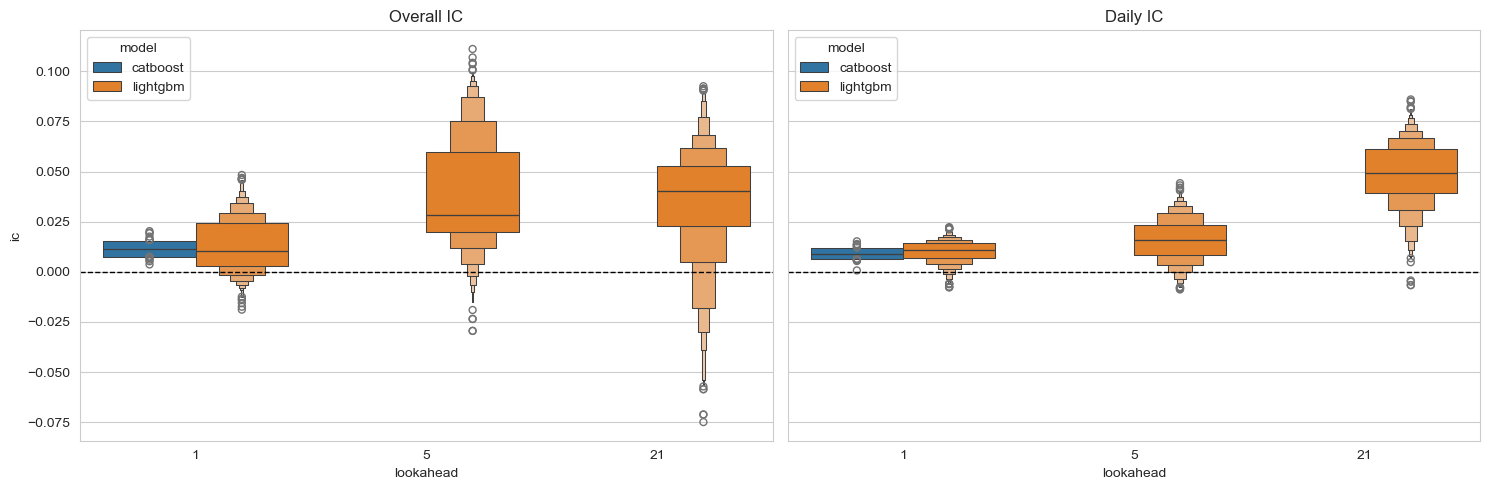

In [29]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)
sns.boxenplot(
    x="lookahead",
    y="ic",
    hue="model",
    data=pd.concat(
        [
            catboost_metrics.assign(model="catboost"),
            lgb_metrics.assign(model="lightgbm"),
        ]
    ),
    ax=axes[0],
)
axes[0].axhline(0, ls="--", lw=1, c="k")
axes[0].set_title("Overall IC")
sns.boxenplot(
    x="lookahead",
    y="ic",
    hue="model",
    data=pd.concat(
        [
            catboost_daily_ic.assign(model="catboost"),
            lgb_daily_ic.assign(model="lightgbm"),
        ]
    ),
    ax=axes[1],
)
axes[1].axhline(0, ls="--", lw=1, c="k")
axes[1].set_title("Daily IC")
fig.tight_layout()

## HyperParameter Impact: Linear Regression

Next, we'd like to understand if there's a systematic, statistical relationship between the hyperparameters and the outcomes across daily predictions. To this end, we will run a linear regression using the various LightGBM hyperparameter settings as dummy variables and the daily validation IC as the outcome.

The below chart shows the coefficient estimates and their confidence intervals for 1- and 21-day forecast horizons. 
- For the shorter horizon, a longer lookback period, a higher learning rate, and deeper trees (more leaf nodes) have a positive impact. 
- For the longer horizon, the picture is a little less clear: shorter trees do better, but the lookback period is not significant. A higher feature sampling rate also helps. In both cases, a larger ensemble does better. 

Note that these results apply to this specific example only.

In [31]:
lin_reg = {}
for t in [1, 21]:
    df_ = lgb_ic[lgb_ic.lookahead == t]
    y, X = df_.ic, df_.drop(["ic"], axis=1)
    X = sm.add_constant(
        pd.get_dummies(X, columns=X.columns, drop_first=True, dtype=int)
    )
    model = sm.OLS(endog=y, exog=X)
    lin_reg[t] = model.fit()
    s = lin_reg[t].summary()
    coefs = pd.read_csv(StringIO(s.tables[1].as_csv())).rename(
        columns=lambda x: x.strip()
    )
    coefs.columns = ["variable", "coef", "std_err", "t", "p_value", "ci_low", "ci_high"]
    coefs.to_csv(f"results/linreg_result_{t:02}.csv", index=False)

In [36]:
import numpy as np

In [37]:
def visualize_lr_result(model, ax):
    ci = model.conf_int()
    errors = ci[1].sub(ci[0]).div(2)

    coefs = (
        model.params.to_frame("coef")
        .assign(error=errors)
        .reset_index()
        .rename(columns={"index": "variable"})
    )
    coefs = coefs[
        ~coefs["variable"].str.startswith("date") & (coefs.variable != "const")
    ]

    coefs.plot(
        x="variable",
        y="coef",
        kind="bar",
        ax=ax,
        color="none",
        capsize=3,
        yerr="error",
        legend=False,
    )
    ax.set_ylabel("IC")
    ax.set_xlabel("")
    ax.scatter(
        x=np.arange(len(coefs)), marker="_", s=120, y=coefs["coef"], color="black"
    )
    ax.axhline(y=0, linestyle="--", color="black", linewidth=1)
    ax.xaxis.set_ticks_position("none")

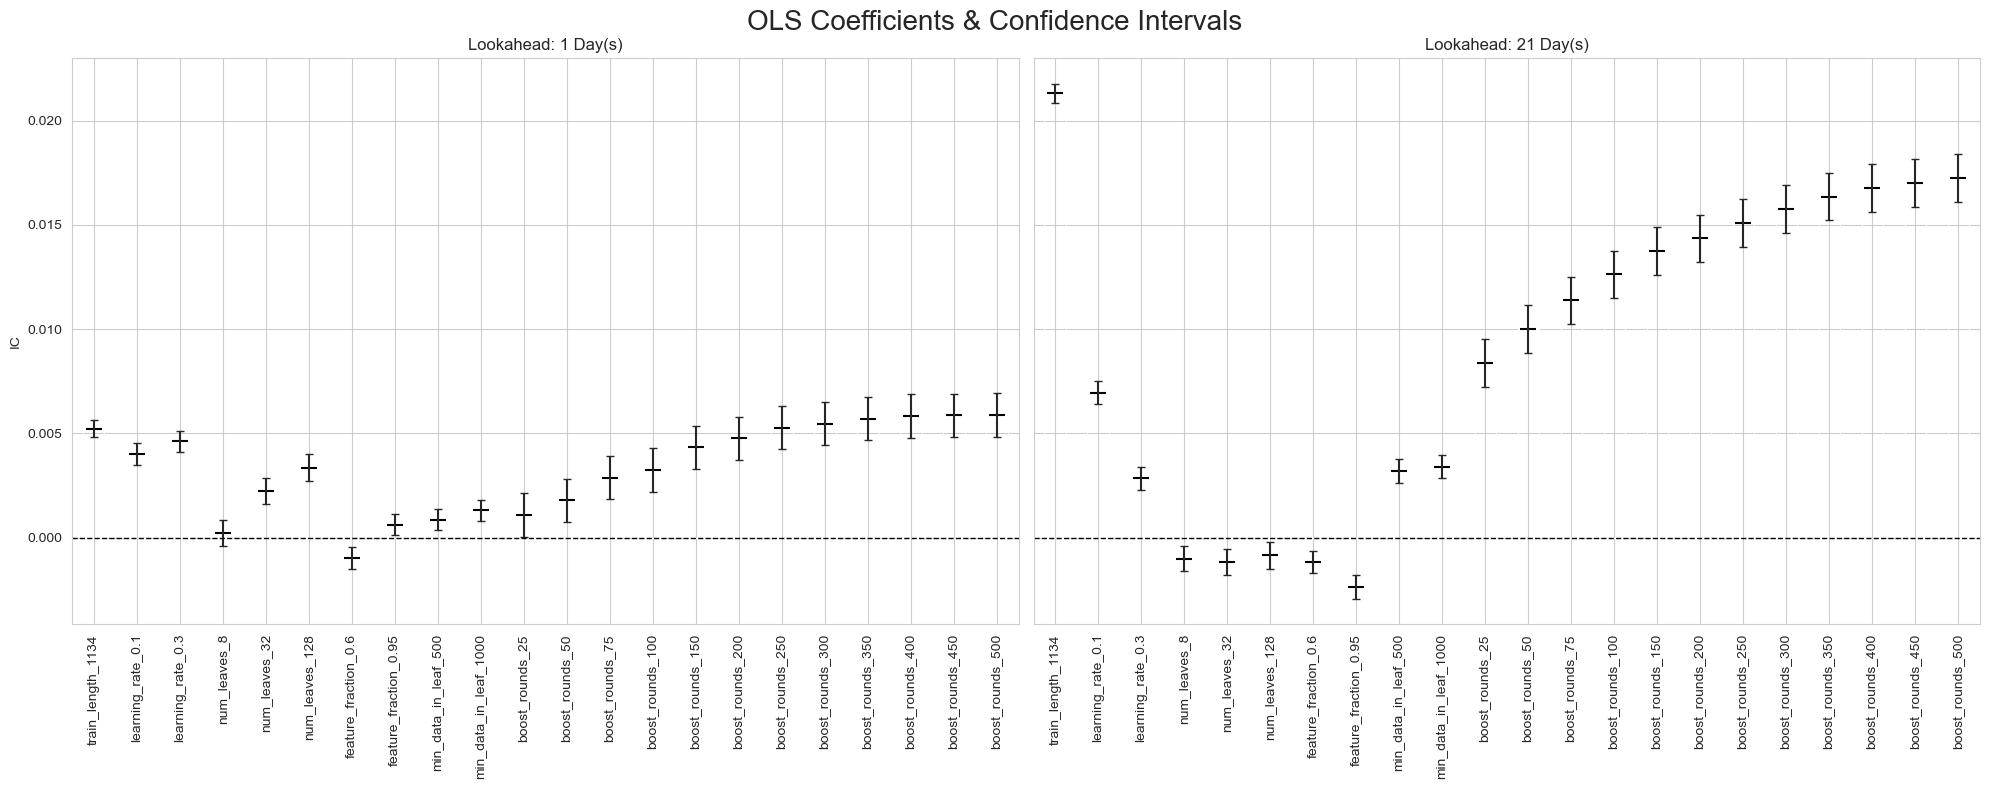

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=True)
axes = axes.flatten()
for i, t in enumerate([1, 21]):
    visualize_lr_result(lin_reg[t], axes[i])
    axes[i].set_title(f"Lookahead: {t} Day(s)")
fig.suptitle("OLS Coefficients & Confidence Intervals", fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=0.92);

## Cross-validation Result: Best Hyperparameters

### LightGBM

The top-performing LightGBM models use the following parameters for the three different prediction horizons.

In [39]:
group_cols = scope_params + lgb_train_params + ["boost_rounds"]
lgb_daily_ic.groupby("lookahead", group_keys=False).apply(lambda x: x.nlargest(3, "ic"))

,lookahead,train_length,test_length,learning_rate,num_leaves,feature_fraction,min_data_in_leaf,boost_rounds,ic
1283,1,1134,63,0.30,32,0.30,500,350,0.022303
1277,1,1134,63,0.30,32,0.30,500,75,0.021918
26,1,252,63,0.01,4,0.95,500,10,0.021761
2462,5,1134,63,0.10,8,0.60,250,150,0.044236
2463,5,1134,63,0.10,8,0.60,250,200,0.043119
2466,5,1134,63,0.10,8,0.60,250,350,0.041982
3774,21,1134,63,0.10,4,0.30,500,100,0.085989
3775,21,1134,63,0.10,4,0.30,500,150,0.085123
3776,21,1134,63,0.10,4,0.30,500,200,0.084886


In [40]:
lgb_metrics.groupby("lookahead", group_keys=False).apply(
    lambda x: x.nlargest(3, "ic")
).to_csv("results/best_lgb_model.csv", index=False)

In [41]:
lgb_metrics.groupby("lookahead", group_keys=False).apply(
    lambda x: x.nlargest(3, "daily_ic_mean")
)

,lookahead,train_length,test_length,learning_rate,num_leaves,feature_fraction,min_data_in_leaf,daily_ic_mean,daily_ic_mean_n,daily_ic_median,daily_ic_median_n,boost_rounds,ic
286,1,1134,63,0.3,32.0,0.3,500.0,0.022303,350.0,0.020459,75.0,10,0.017198
610,1,1134,63,0.3,32.0,0.3,500.0,0.022303,350.0,0.020459,75.0,25,0.028550
934,1,1134,63,0.3,32.0,0.3,500.0,0.022303,350.0,0.020459,75.0,50,0.010049
71,5,1134,63,0.1,8.0,0.6,250.0,0.044236,150.0,0.032264,100.0,10,0.012090
395,5,1134,63,0.1,8.0,0.6,250.0,0.044236,150.0,0.032264,100.0,25,0.054402
719,5,1134,63,0.1,8.0,0.6,250.0,0.044236,150.0,0.032264,100.0,50,0.069841
187,21,1134,63,0.1,4.0,0.3,500.0,0.085989,100.0,0.098346,100.0,10,0.031163
511,21,1134,63,0.1,4.0,0.3,500.0,0.085989,100.0,0.098346,100.0,25,0.054512
835,21,1134,63,0.1,4.0,0.3,500.0,0.085989,100.0,0.098346,100.0,50,0.078123


### CatBoost

In [42]:
group_cols = scope_params + catboost_train_params + ["boost_rounds"]
catboost_daily_ic.groupby("lookahead", group_keys=False).apply(
    lambda x: x.nlargest(3, "ic")
)

,lookahead,train_length,test_length,max_depth,min_child_samples,boost_rounds,ic
16,1,1134,63,5,250,50,0.015211
18,1,1134,63,5,250,100,0.013893
15,1,1134,63,5,250,25,0.013493


In [44]:
catboost_metrics.groupby("lookahead", group_keys=False).apply(
    lambda x: x.nlargest(3, "daily_ic_mean")
)

,lookahead,train_length,test_length,max_depth,min_child_samples,daily_ic_mean,daily_ic_mean_n,daily_ic_median,daily_ic_median_n,boost_rounds,ic
1,1,1134,63,5.0,250.0,0.015211,50.0,0.012729,25.0,10,0.003680
3,1,1134,63,5.0,250.0,0.015211,50.0,0.012729,25.0,25,0.007569
5,1,1134,63,5.0,250.0,0.015211,50.0,0.012729,25.0,50,0.007323


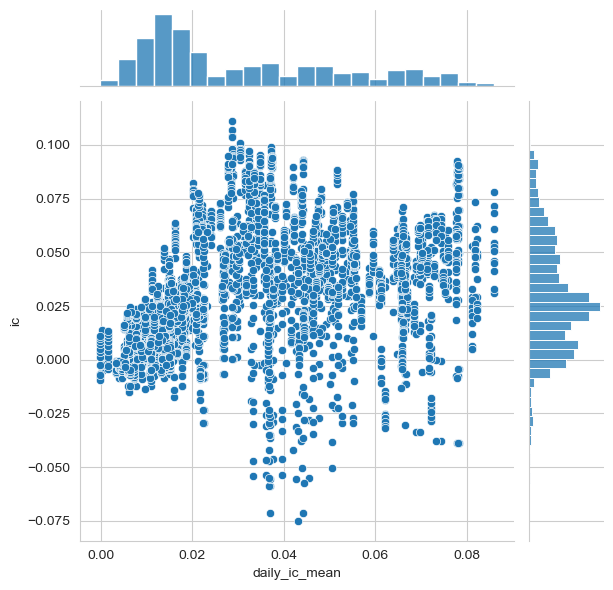

In [45]:
sns.jointplot(x=lgb_metrics.daily_ic_mean, y=lgb_metrics.ic);

### Visualization

#### LightGBM

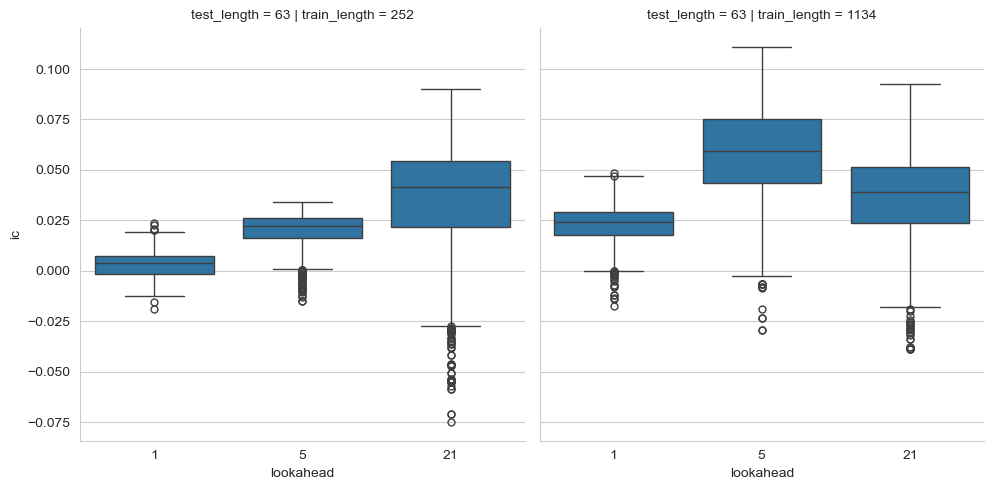

In [46]:
g = sns.catplot(
    x="lookahead",
    y="ic",
    col="train_length",
    row="test_length",
    data=lgb_metrics,
    kind="box",
)

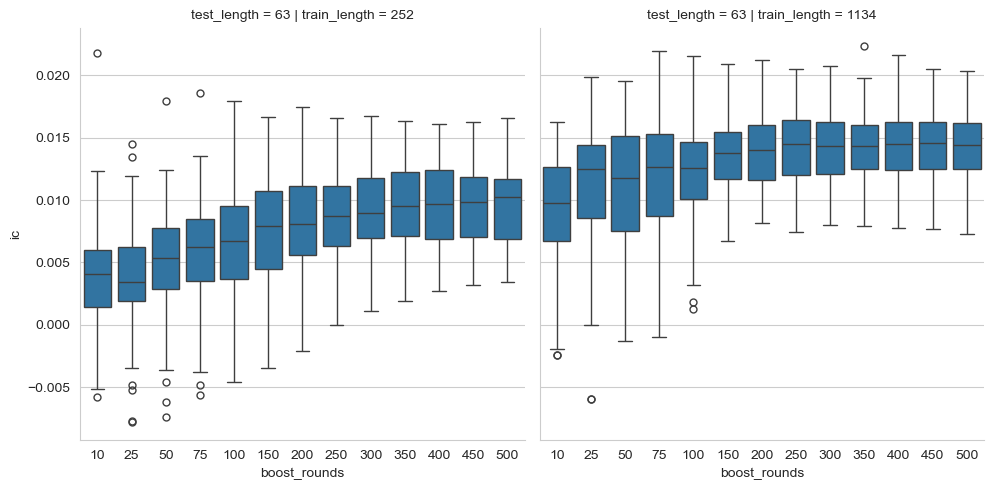

In [47]:
t = 1
g = sns.catplot(
    x="boost_rounds",
    y="ic",
    col="train_length",
    row="test_length",
    data=lgb_daily_ic[lgb_daily_ic.lookahead == t],
    kind="box",
)

#### CatBoost

Some figures are empty because we did not run those parameter combinations.

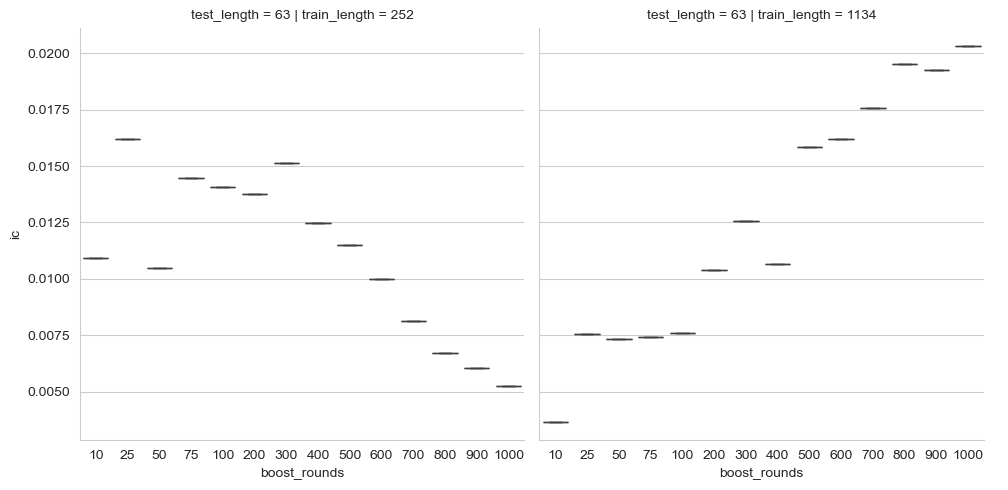

In [48]:
t = 1
g = sns.catplot(
    x="boost_rounds",
    y="ic",
    col="train_length",
    row="test_length",
    data=catboost_metrics[catboost_metrics.lookahead == t],
    kind="box",
)

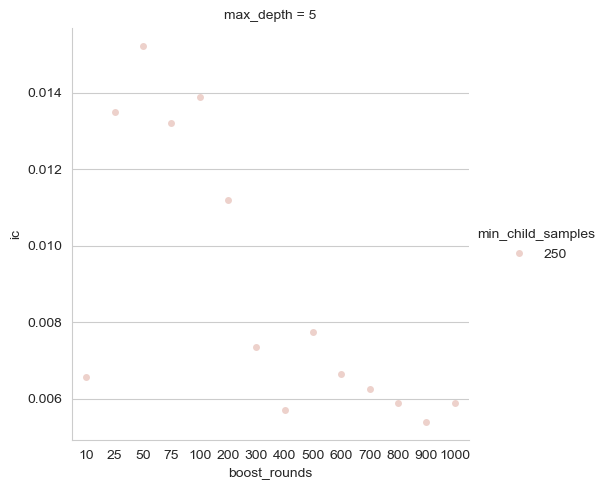

In [49]:
t = 1
train_length = 1134
test_length = 63
g = sns.catplot(
    x="boost_rounds",
    y="ic",
    col="max_depth",
    hue="min_child_samples",
    data=catboost_daily_ic[
        (catboost_daily_ic.lookahead == t)
        & (catboost_daily_ic.train_length == train_length)
        & (catboost_daily_ic.test_length == test_length)
    ],
    kind="swarm",
)

## AlphaLens Analysis - Validation Performance

### LightGBM

#### Select Parameters

In [50]:
lgb_daily_ic = pd.read_hdf("data/model_tuning.h5", "lgb/daily_ic")
lgb_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4212 entries, 0 to 4211
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   lookahead         4212 non-null   int64  
 1   train_length      4212 non-null   int64  
 2   test_length       4212 non-null   int64  
 3   learning_rate     4212 non-null   float64
 4   num_leaves        4212 non-null   int64  
 5   feature_fraction  4212 non-null   float64
 6   min_data_in_leaf  4212 non-null   int64  
 7   boost_rounds      4212 non-null   int64  
 8   ic                4212 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 329.1 KB


In [51]:
def get_lgb_params(data, t=5, best=0):
    param_cols = scope_params[1:] + lgb_train_params + ["boost_rounds"]
    df = data[data.lookahead == t].sort_values("ic", ascending=False).iloc[best]
    return df.loc[param_cols]

In [52]:
def get_lgb_key(t, p):
    key = f"{t}/{int(p.train_length)}/{int(p.test_length)}/{p.learning_rate}/"
    return key + f"{int(p.num_leaves)}/{p.feature_fraction}/{int(p.min_data_in_leaf)}"

In [53]:
best_params = get_lgb_params(lgb_daily_ic, t=1, best=0)
best_params

train_length        1134.0
test_length           63.0
learning_rate          0.3
num_leaves            32.0
feature_fraction       0.3
min_data_in_leaf     500.0
boost_rounds         350.0
Name: 1283, dtype: float64

In [54]:
best_params.to_hdf("data.h5", "best_params")

#### Plot rolling IC

In [55]:
def select_ic(params, ic_data, lookahead):
    return ic_data.loc[
        (ic_data.lookahead == lookahead)
        & (ic_data.train_length == params.train_length)
        & (ic_data.test_length == params.test_length)
        & (ic_data.learning_rate == params.learning_rate)
        & (ic_data.num_leaves == params.num_leaves)
        & (ic_data.feature_fraction == params.feature_fraction)
        & (ic_data.boost_rounds == params.boost_rounds),
        ["date", "ic"],
    ].set_index("date")

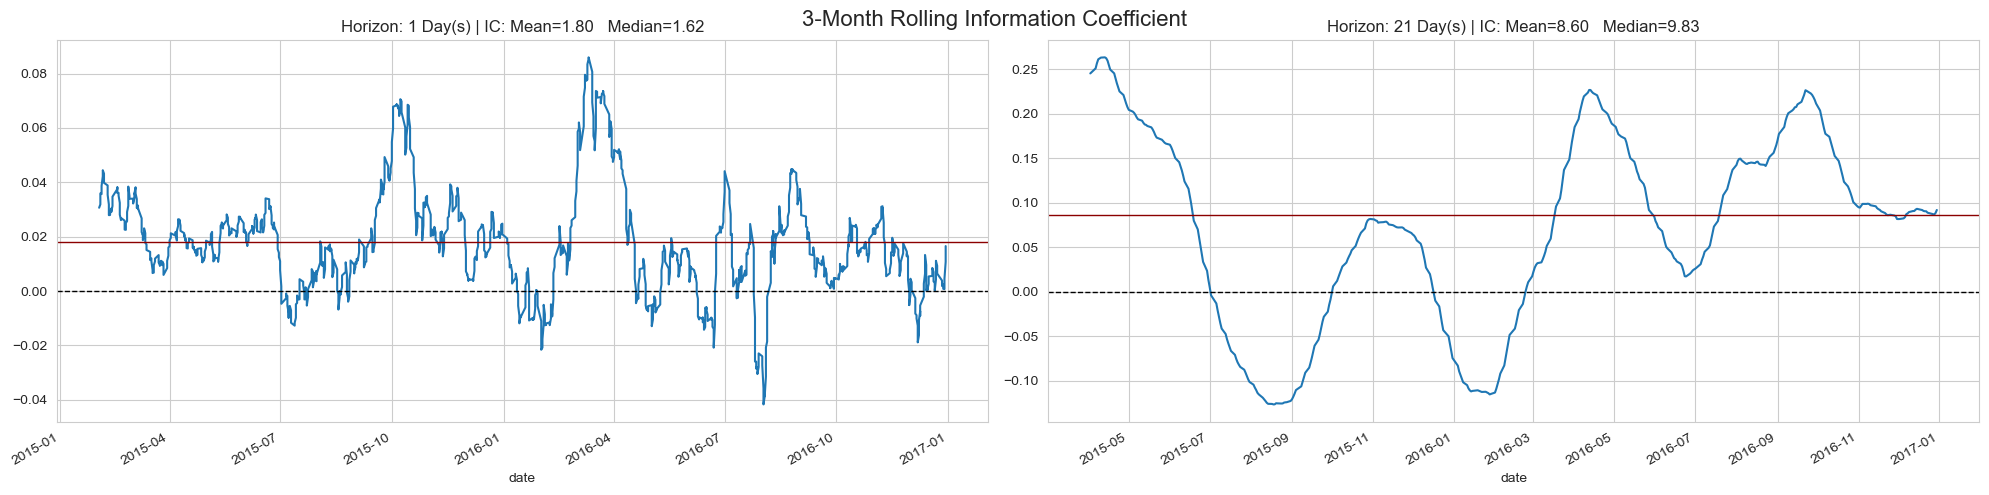

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axes = axes.flatten()
for i, t in enumerate([1, 21]):
    params = get_lgb_params(lgb_daily_ic, t=t)
    data = select_ic(params, lgb_ic, lookahead=t).sort_index()
    rolling = data.rolling(63).ic.mean().dropna()
    avg = data.ic.mean()
    med = data.ic.median()
    rolling.plot(
        ax=axes[i],
        title=f"Horizon: {t} Day(s) | IC: Mean={avg * 100:.2f}   Median={med * 100:.2f}",
    )
    axes[i].axhline(avg, c="darkred", lw=1)
    axes[i].axhline(0, ls="--", c="k", lw=1)

fig.suptitle("3-Month Rolling Information Coefficient", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.92);

#### Get Predictions for Validation Period

We retrieve the predictions for the 10 validation runs:

In [57]:
lookahead = 1
topn = 10
for best in range(topn):
    best_params = get_lgb_params(lgb_daily_ic, t=lookahead, best=best)
    key = get_lgb_key(lookahead, best_params)
    rounds = str(int(best_params.boost_rounds))
    if best == 0:
        best_predictions = pd.read_hdf(
            results_path / "tuning_lgb.h5", "predictions/" + key
        )
        best_predictions = best_predictions[rounds].to_frame(best)
    else:
        best_predictions[best] = pd.read_hdf(
            results_path / "tuning_lgb.h5", "predictions/" + key
        )[rounds]
best_predictions = best_predictions.sort_index()

In [58]:
best_predictions.to_hdf("data/predictions.h5", f"lgb/train/{lookahead:02}")
best_predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501310 entries, ('A', Timestamp('2015-01-02 00:00:00')) to ('ZION', Timestamp('2016-12-30 00:00:00'))
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       501310 non-null  float64
 1   1       501310 non-null  float64
 2   2       501310 non-null  float64
 3   3       501310 non-null  float64
 4   4       501310 non-null  float64
 5   5       501310 non-null  float64
 6   6       501310 non-null  float64
 7   7       501310 non-null  float64
 8   8       501310 non-null  float64
 9   9       501310 non-null  float64
dtypes: float64(10)
memory usage: 40.9+ MB


#### Get Trade Prices

Using next available prices.

In [59]:
def get_trade_prices(tickers):
    idx = pd.IndexSlice
    DATA_STORE = "../data/assets.h5"
    prices = pd.read_hdf(DATA_STORE, "quandl/wiki/prices").swaplevel().sort_index()
    prices.index.names = ["symbol", "date"]
    return (
        prices.loc[idx[tickers, "2015":"2017"], "adj_open"]
        .unstack("symbol")
        .sort_index()
        .shift(-1)
        .tz_localize("UTC")
    )

In [60]:
test_tickers = best_predictions.index.get_level_values("symbol").unique()

In [61]:
trade_prices = get_trade_prices(test_tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2015-01-02 00:00:00+00:00 to 2017-12-29 00:00:00+00:00
Columns: 995 entries, A to ZION
dtypes: float64(995)
memory usage: 5.7 MB


In [62]:
# persist result in case we want to rerun:
trade_prices.to_hdf("data/model_tuning.h5", "trade_prices/model_selection")
trade_prices = pd.read_hdf("data/model_tuning.h5", "trade_prices/model_selection")

We average the top five models and provide the corresponding prices to Alphalens, in order to compute the mean period-wise return earned on an equal-weighted portfolio invested in the daily factor quintiles for various holding periods:

In [63]:
factor = (
    best_predictions.iloc[:, :5]
    .mean(1)
    .dropna()
    .tz_localize("UTC", level="date")
    .swaplevel()
)

#### Create AlphaLens Inputs

In [65]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=5, periods=(1, 5, 10, 21)
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


#### Compute Alphalens metrics

In [66]:
mean_quant_ret_bydate, std_quant_daily = perf.mean_return_by_quantile(
    factor_data,
    by_date=True,
    by_group=False,
    demeaned=True,
    group_adjust=False,
)

In [67]:
factor_returns = perf.factor_returns(factor_data)

In [68]:
mean_quant_ret, std_quantile = perf.mean_return_by_quantile(
    factor_data, by_group=False, demeaned=True
)


mean_quant_rateret = mean_quant_ret.apply(
    rate_of_return, axis=0, base_period=mean_quant_ret.columns[0]
)

In [69]:
mean_quant_ret_bydate, std_quant_daily = perf.mean_return_by_quantile(
    factor_data,
    by_date=True,
    by_group=False,
    demeaned=True,
    group_adjust=False,
)

mean_quant_rateret_bydate = mean_quant_ret_bydate.apply(
    rate_of_return,
    base_period=mean_quant_ret_bydate.columns[0],
)

compstd_quant_daily = std_quant_daily.apply(
    std_conversion, base_period=std_quant_daily.columns[0]
)

alpha_beta = perf.factor_alpha_beta(factor_data, demeaned=True)

mean_ret_spread_quant, std_spread_quant = perf.compute_mean_returns_spread(
    mean_quant_rateret_bydate,
    factor_data["factor_quantile"].max(),
    factor_data["factor_quantile"].min(),
    std_err=compstd_quant_daily,
)

In [70]:
mean_ret_spread_quant.mean().mul(10000).to_frame("Mean Period Wise Spread (bps)").join(
    alpha_beta.T
).T

,1D,5D,10D,21D
Mean Period Wise Spread (bps),11.596815,6.030512,4.642980,4.293920
Ann. alpha,0.171981,0.070154,0.050182,0.043325
beta,0.041499,0.080269,0.085277,0.099535


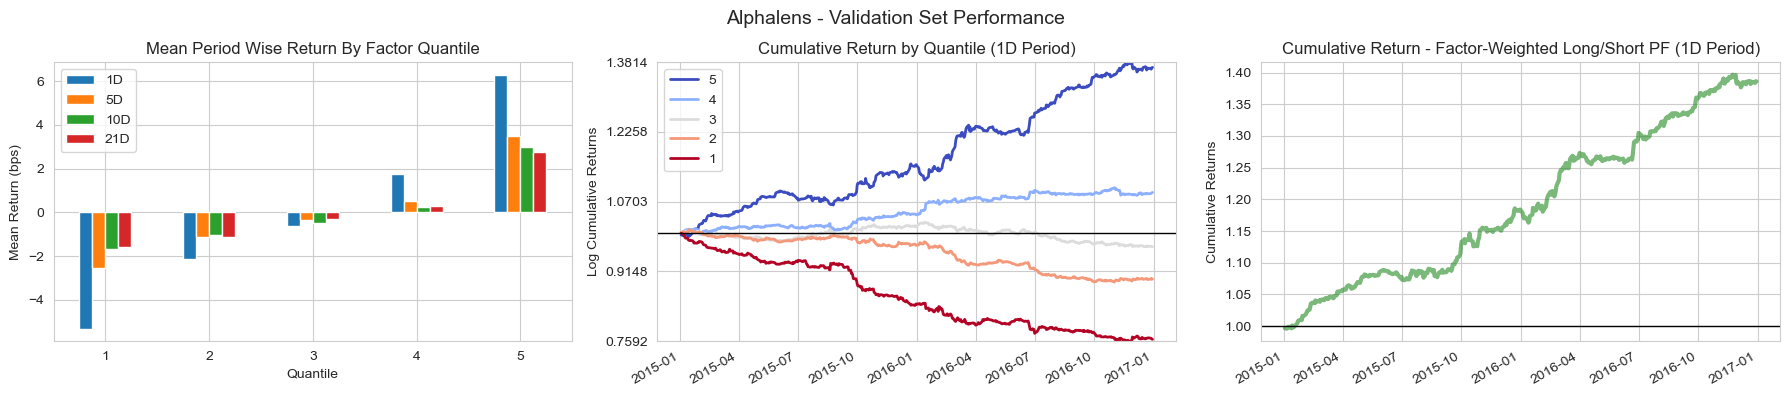

In [71]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 4))


plotting.plot_quantile_returns_bar(mean_quant_rateret, ax=axes[0])
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)
axes[0].set_xlabel("Quantile")

plotting.plot_cumulative_returns_by_quantile(
    mean_quant_ret_bydate["1D"], freq=pd.tseries.offsets.BDay(), period="1D", ax=axes[1]
)
axes[1].set_title("Cumulative Return by Quantile (1D Period)")

title = "Cumulative Return - Factor-Weighted Long/Short PF (1D Period)"
plotting.plot_cumulative_returns(
    factor_returns["1D"],
    period="1D",
    freq=pd.tseries.offsets.BDay(),
    title=title,
    ax=axes[2],
)

fig.suptitle("Alphalens - Validation Set Performance", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85);

#### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.040399,0.006709,-0.004278,0.004859,100296,20.006902
2,-0.014322,0.012485,-0.002009,0.004164,100247,19.997128
3,-0.012554,0.016047,-0.000865,0.004119,100221,19.991941
4,-0.011553,0.020464,0.000216,0.004275,100247,19.997128
5,-0.010571,0.048677,0.002447,0.005351,100296,20.006902


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.172,0.070,0.050,0.043
beta,0.041,0.080,0.085,0.100
Mean Period Wise Return Top Quantile (bps),6.288,3.503,2.981,2.740
Mean Period Wise Return Bottom Quantile (bps),-5.308,-2.539,-1.681,-1.569
Mean Period Wise Spread (bps),11.597,6.031,4.643,4.294


Information Analysis


,1D,5D,10D,21D
IC Mean,0.022,0.023,0.026,0.043
IC Std.,0.102,0.108,0.110,0.104
Risk-Adjusted IC,0.212,0.212,0.241,0.412
t-stat(IC),4.755,4.769,5.406,9.258
p-value(IC),0.000,0.000,0.000,0.000
IC Skew,0.204,0.333,0.219,0.160
IC Kurtosis,0.880,0.761,0.534,0.537


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.610,0.683,0.734,0.768
Quantile 2 Mean Turnover,0.740,0.763,0.777,0.791
Quantile 3 Mean Turnover,0.754,0.776,0.784,0.788
Quantile 4 Mean Turnover,0.738,0.762,0.779,0.788
Quantile 5 Mean Turnover,0.610,0.680,0.725,0.761


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.35,0.219,0.119,0.047


<Figure size 640x480 with 0 Axes>

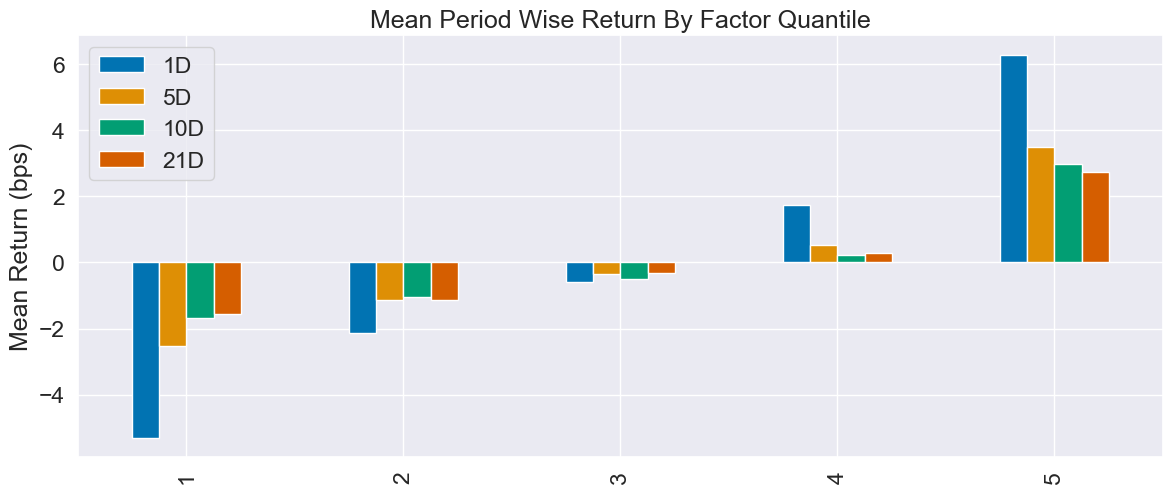

In [72]:
create_summary_tear_sheet(factor_data)

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.040399,0.006709,-0.004278,0.004859,100296,20.006902
2,-0.014322,0.012485,-0.002009,0.004164,100247,19.997128
3,-0.012554,0.016047,-0.000865,0.004119,100221,19.991941
4,-0.011553,0.020464,0.000216,0.004275,100247,19.997128
5,-0.010571,0.048677,0.002447,0.005351,100296,20.006902


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.172,0.070,0.050,0.043
beta,0.041,0.080,0.085,0.100
Mean Period Wise Return Top Quantile (bps),6.288,3.503,2.981,2.740
Mean Period Wise Return Bottom Quantile (bps),-5.308,-2.539,-1.681,-1.569
Mean Period Wise Spread (bps),11.597,6.031,4.643,4.294


<Figure size 640x480 with 0 Axes>

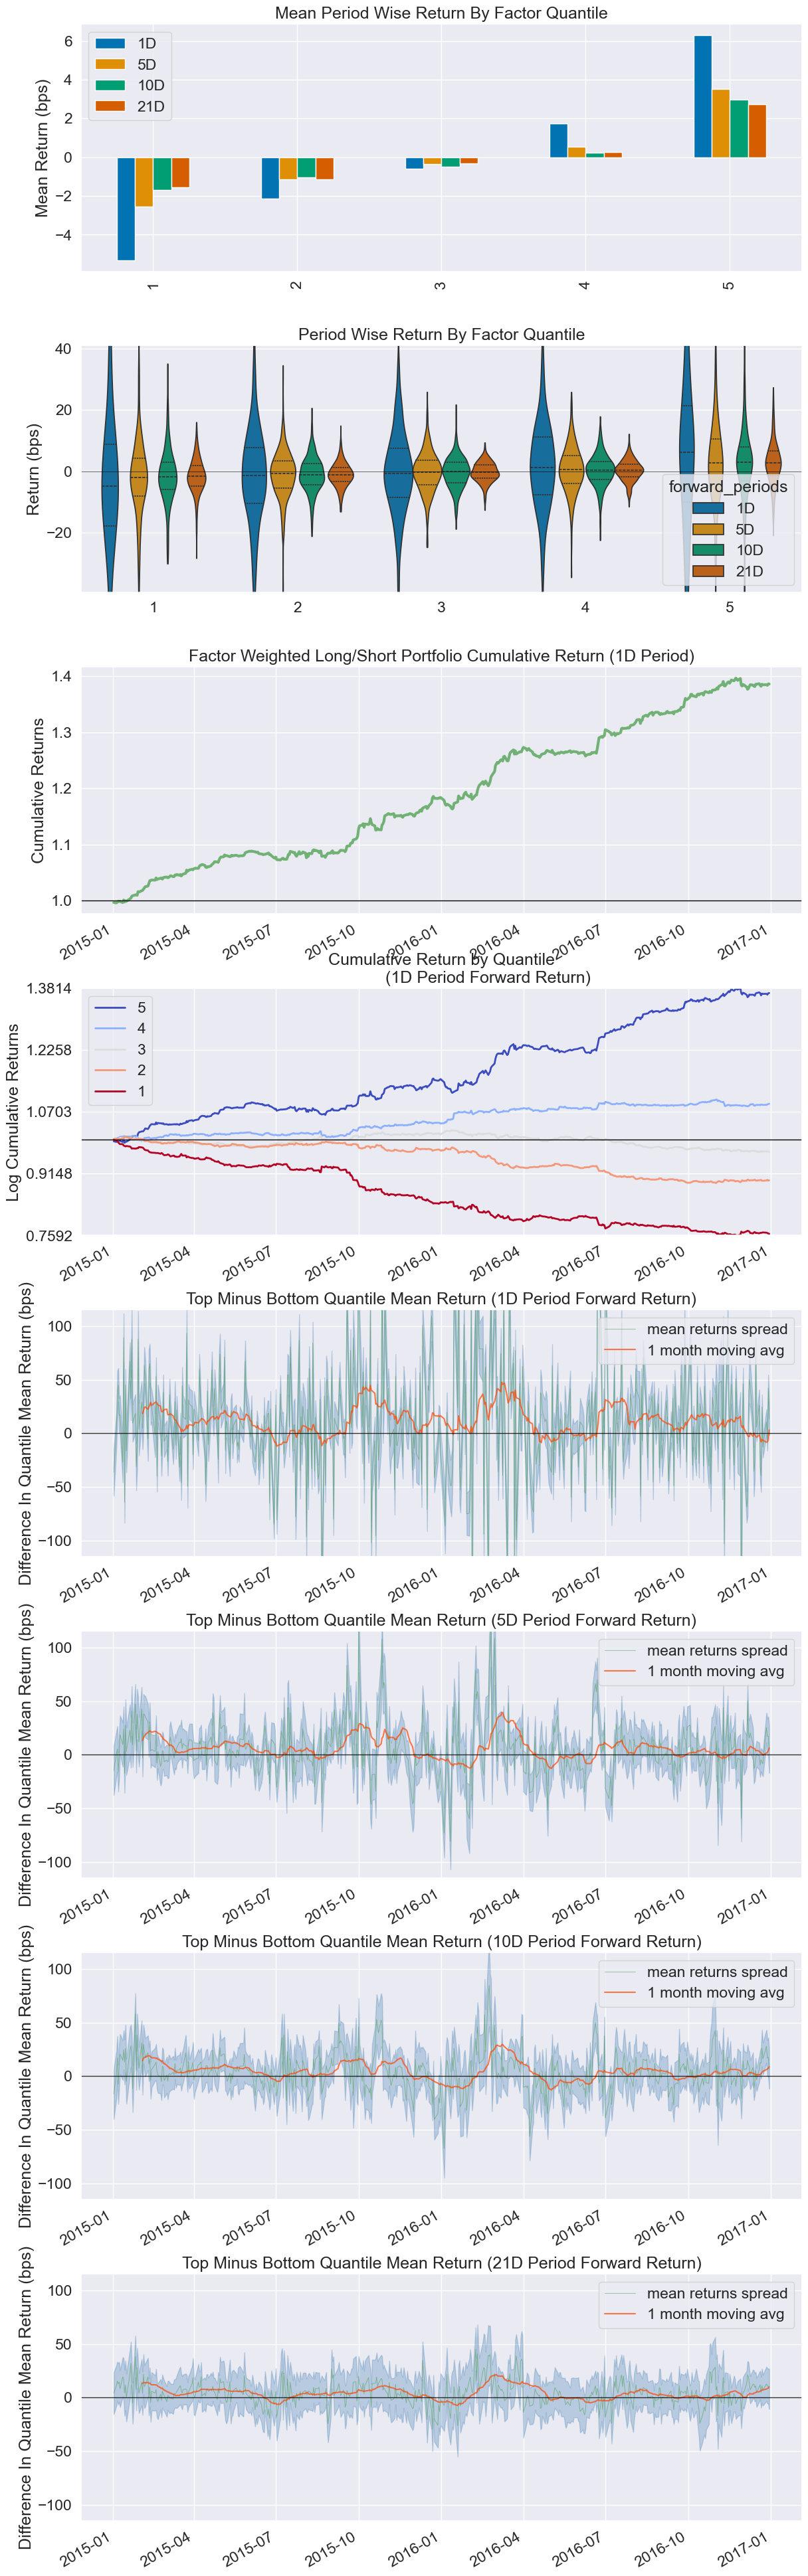

Information Analysis


,1D,5D,10D,21D
IC Mean,0.022,0.023,0.026,0.043
IC Std.,0.102,0.108,0.110,0.104
Risk-Adjusted IC,0.212,0.212,0.241,0.412
t-stat(IC),4.755,4.769,5.406,9.258
p-value(IC),0.000,0.000,0.000,0.000
IC Skew,0.204,0.333,0.219,0.160
IC Kurtosis,0.880,0.761,0.534,0.537


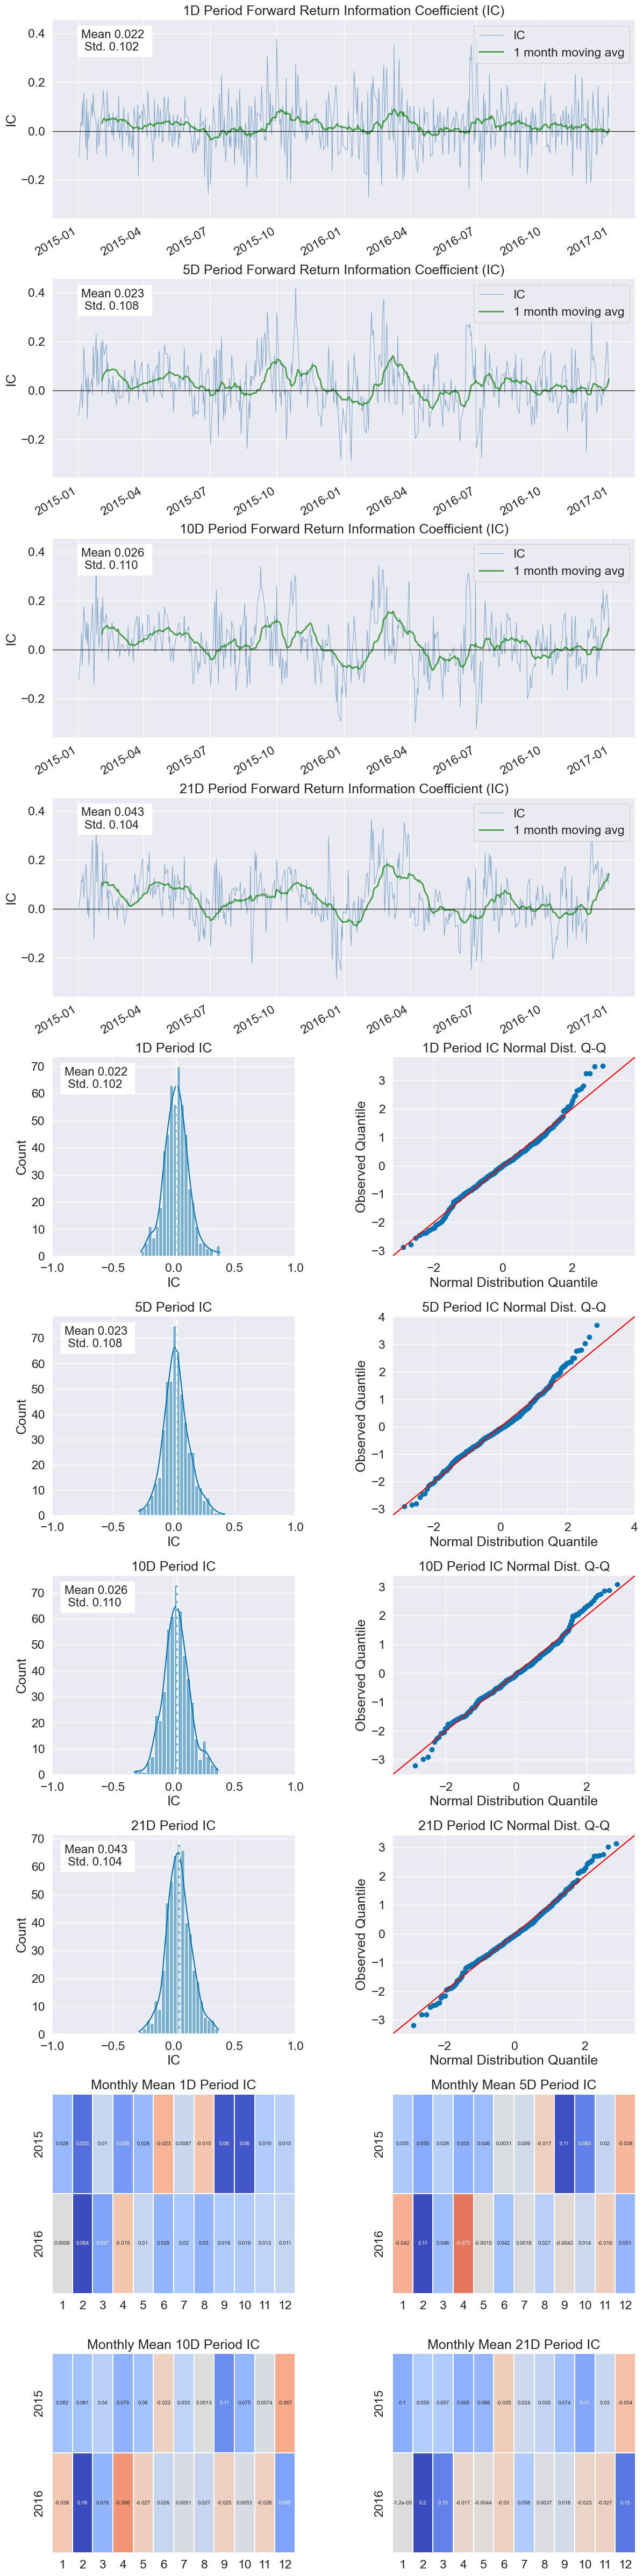

Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.610,0.683,0.734,0.768
Quantile 2 Mean Turnover,0.740,0.763,0.777,0.791
Quantile 3 Mean Turnover,0.754,0.776,0.784,0.788
Quantile 4 Mean Turnover,0.738,0.762,0.779,0.788
Quantile 5 Mean Turnover,0.610,0.680,0.725,0.761


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.35,0.219,0.119,0.047


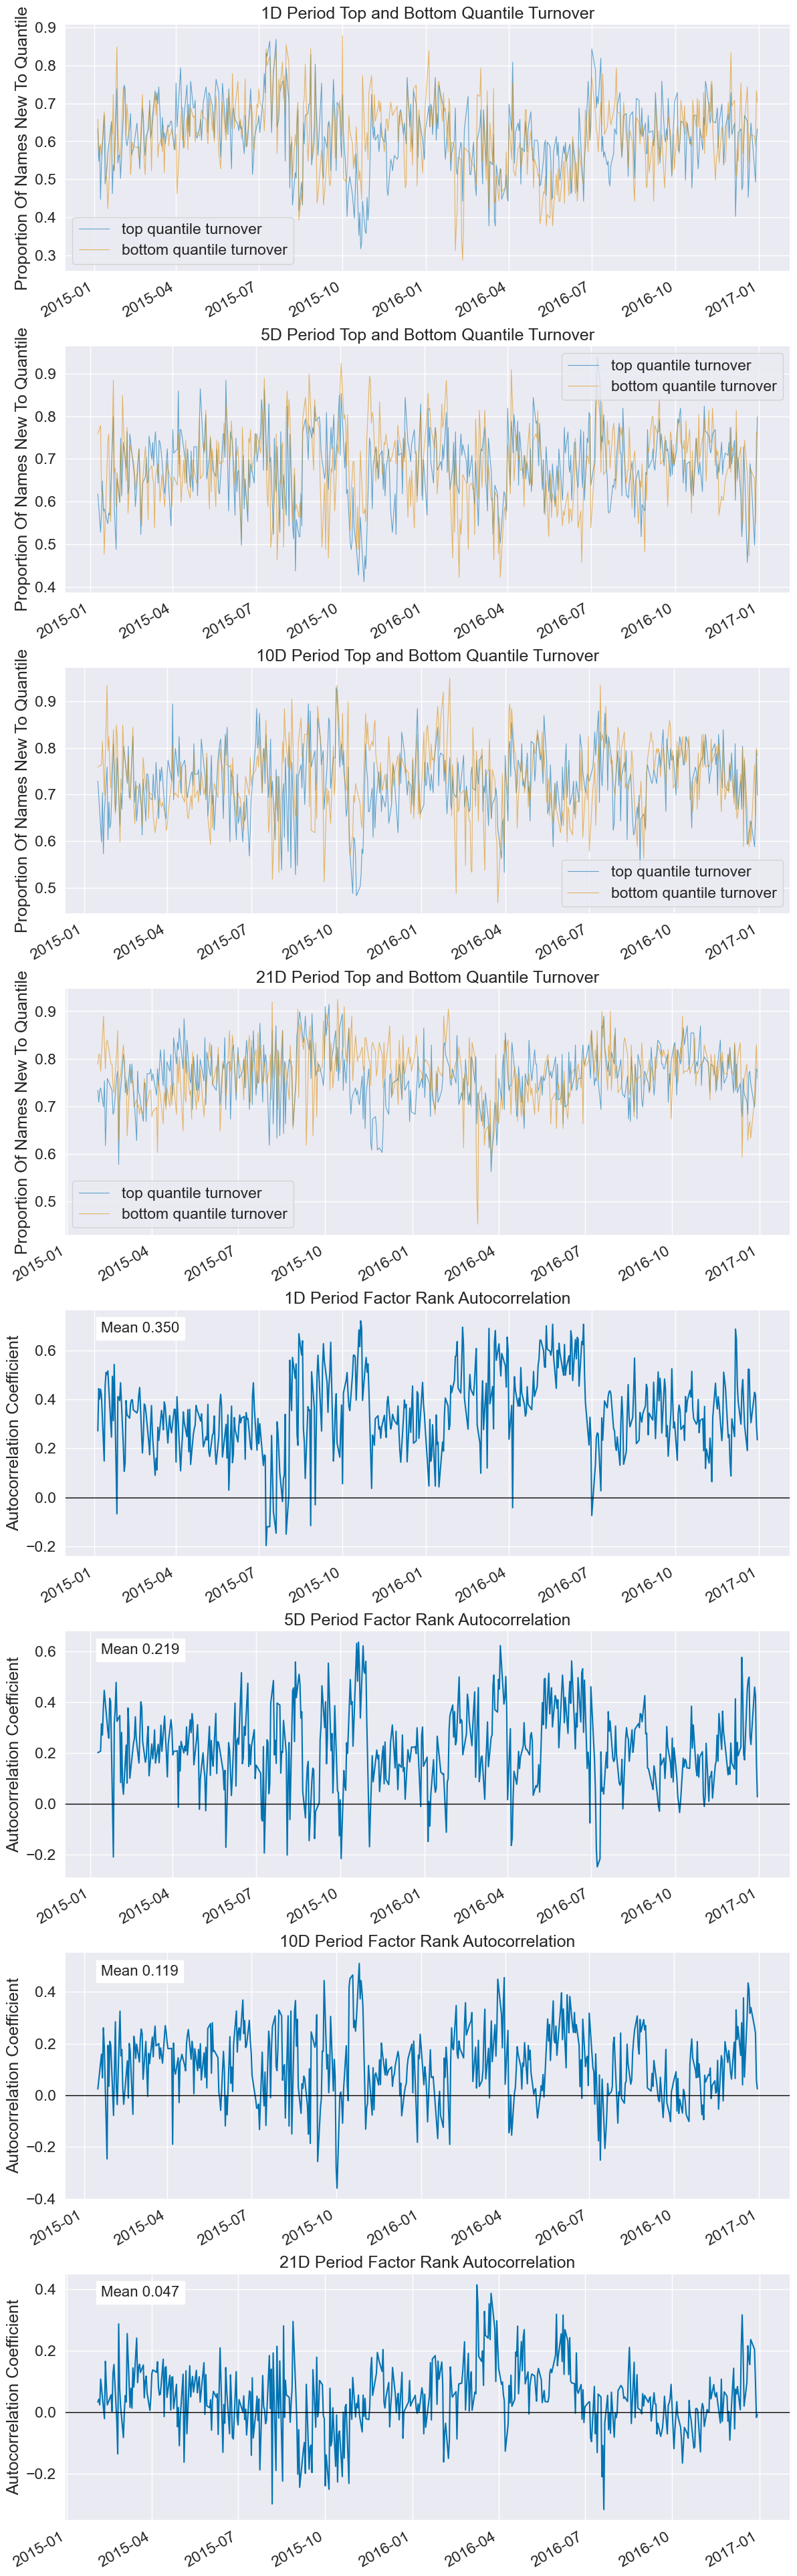

In [73]:
create_full_tear_sheet(factor_data)

### CatBoost

#### Select Parameters

In [74]:
catboost_daily_ic = pd.read_hdf("data/model_tuning.h5", "catboost/daily_ic")
catboost_daily_ic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 0 to 27
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lookahead          28 non-null     int64  
 1   train_length       28 non-null     int64  
 2   test_length        28 non-null     int64  
 3   max_depth          28 non-null     int64  
 4   min_child_samples  28 non-null     int64  
 5   boost_rounds       28 non-null     int64  
 6   ic                 28 non-null     float64
dtypes: float64(1), int64(6)
memory usage: 1.8 KB


In [75]:
def get_cb_params(data, t=5, best=0):
    param_cols = scope_params[1:] + catboost_train_params + ["boost_rounds"]
    df = data[data.lookahead == t].sort_values("ic", ascending=False).iloc[best]
    return df.loc[param_cols]

In [76]:
def get_cb_key(t, p):
    key = f"{t}/{int(p.train_length)}/{int(p.test_length)}/"
    return key + f"{int(p.max_depth)}/{int(p.min_child_samples)}"

In [77]:
best_params = get_cb_params(catboost_daily_ic, t=1, best=0)
best_params

train_length         1134.0
test_length            63.0
max_depth               5.0
min_child_samples     250.0
boost_rounds           50.0
Name: 16, dtype: float64

In [78]:
def select_cb_ic(params, ic_data, lookahead):
    return ic_data.loc[
        (ic_data.lookahead == lookahead)
        & (ic_data.train_length == params.train_length)
        & (ic_data.test_length == params.test_length)
        & (ic_data.max_depth == params.max_depth)
        & (ic_data.min_child_samples == params.min_child_samples)
    ].set_index("date")

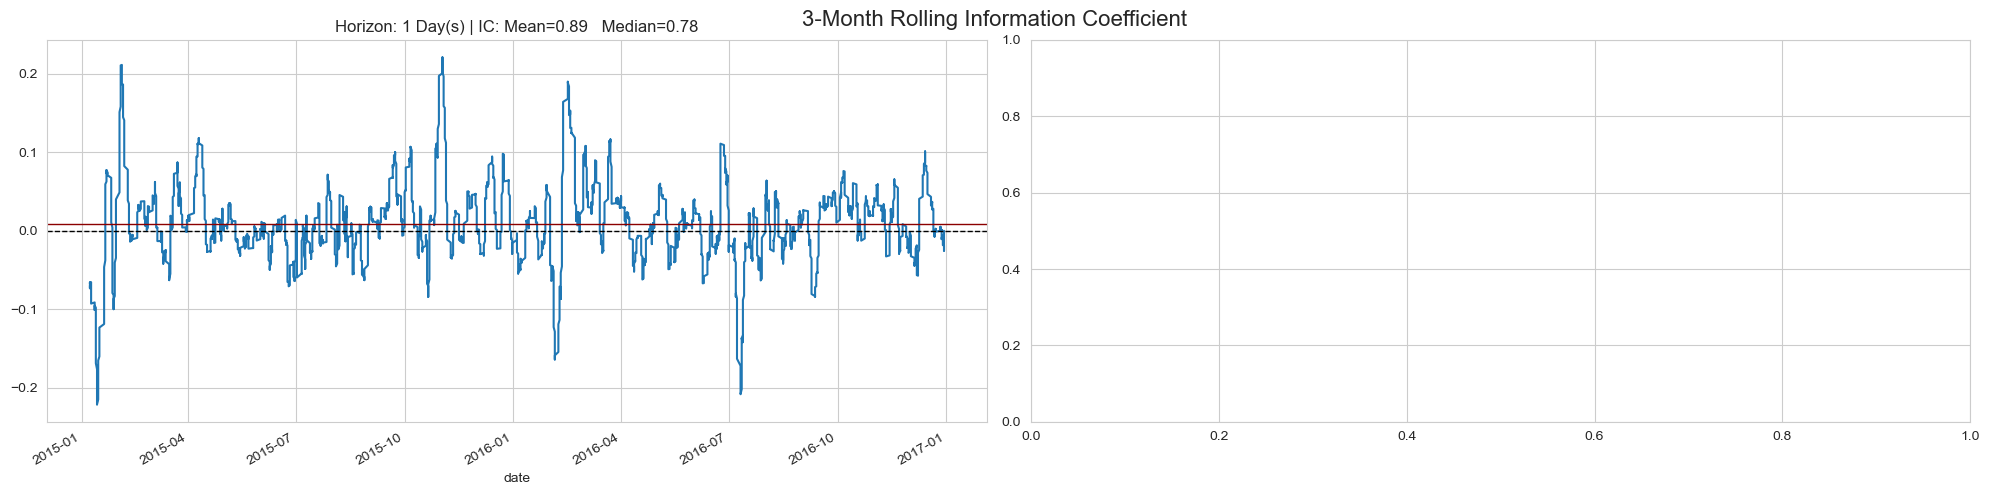

In [80]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axes = axes.flatten()
for i, t in enumerate([1]):
    params = get_cb_params(catboost_daily_ic, t=t)
    data = select_cb_ic(params, catboost_ic, lookahead=t).sort_index()
    rolling = data.rolling(63).ic.mean().dropna()
    avg = data.ic.mean()
    med = data.ic.median()
    rolling.plot(
        ax=axes[i],
        title=f"Horizon: {t} Day(s) | IC: Mean={avg * 100:.2f}   Median={med * 100:.2f}",
    )
    axes[i].axhline(avg, c="darkred", lw=1)
    axes[i].axhline(0, ls="--", c="k", lw=1)

fig.suptitle("3-Month Rolling Information Coefficient", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.92);

#### Get Predictions

In [96]:
best_predictions = pd.read_hdf(
    results_path / "tuning_catboost.h5", "predictions/1/1134/63"
)
best_predictions = best_predictions.loc[:, "1000"].to_frame(best)
best_predictions = best_predictions.sort_index()

In [98]:
best_predictions.to_hdf("data/predictions.h5", f"catboost/train/{lookahead:02}")
best_predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501310 entries, ('A', Timestamp('2015-01-02 00:00:00')) to ('ZION', Timestamp('2016-12-30 00:00:00'))
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       501310 non-null  float64
dtypes: float64(1)
memory usage: 6.5+ MB


#### Get Trade Prices

Using next available prices.

In [99]:
def get_trade_prices(tickers):
    idx = pd.IndexSlice
    DATA_STORE = "../data/assets.h5"
    prices = pd.read_hdf(DATA_STORE, "quandl/wiki/prices").swaplevel().sort_index()
    prices.index.names = ["symbol", "date"]
    return (
        prices.loc[idx[tickers, "2015":"2017"], "adj_open"]
        .unstack("symbol")
        .sort_index()
        .shift(-1)
        .tz_localize("UTC")
    )

In [100]:
test_tickers = best_predictions.index.get_level_values("symbol").unique()

In [101]:
trade_prices = get_trade_prices(test_tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2015-01-02 00:00:00+00:00 to 2017-12-29 00:00:00+00:00
Columns: 995 entries, A to ZION
dtypes: float64(995)
memory usage: 5.7 MB


In [102]:
# only generate once to save time
trade_prices.to_hdf("data/model_tuning.h5", "trade_prices/model_selection")

In [103]:
trade_prices = pd.read_hdf("data/model_tuning.h5", "trade_prices/model_selection")

In [104]:
factor = (
    best_predictions.iloc[:, :1]
    .mean(1)
    .dropna()
    .tz_localize("UTC", level="date")
    .swaplevel()
)

#### Create AlphaLens Inputs

In [105]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=5, periods=(1, 5, 10, 21)
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


#### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.121289,0.023201,-0.003619,0.006547,100296,20.006902
2,-0.022556,0.031124,-0.000310,0.005970,100247,19.997128
3,-0.017814,0.038860,0.001305,0.006268,100221,19.991941
4,-0.015327,0.048281,0.002870,0.006750,100247,19.997128
5,-0.013268,0.095294,0.005995,0.008496,100296,20.006902


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.063,0.040,0.036,0.026
beta,0.006,0.041,0.061,0.121
Mean Period Wise Return Top Quantile (bps),1.795,1.532,1.722,1.650
Mean Period Wise Return Bottom Quantile (bps),-1.950,-1.328,-0.935,-0.779
Mean Period Wise Spread (bps),3.745,2.856,2.647,2.418


Information Analysis


,1D,5D,10D,21D
IC Mean,0.006,0.009,0.012,0.021
IC Std.,0.124,0.134,0.133,0.133
Risk-Adjusted IC,0.049,0.065,0.089,0.157
t-stat(IC),1.103,1.470,1.988,3.517
p-value(IC),0.270,0.142,0.047,0.000
IC Skew,-0.389,-0.460,-0.128,-0.207
IC Kurtosis,1.608,3.041,1.596,1.114


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.524,0.623,0.683,0.731
Quantile 2 Mean Turnover,0.710,0.749,0.771,0.788
Quantile 3 Mean Turnover,0.737,0.765,0.778,0.788
Quantile 4 Mean Turnover,0.713,0.753,0.770,0.786
Quantile 5 Mean Turnover,0.533,0.632,0.702,0.762


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.491,0.318,0.193,0.085


<Figure size 640x480 with 0 Axes>

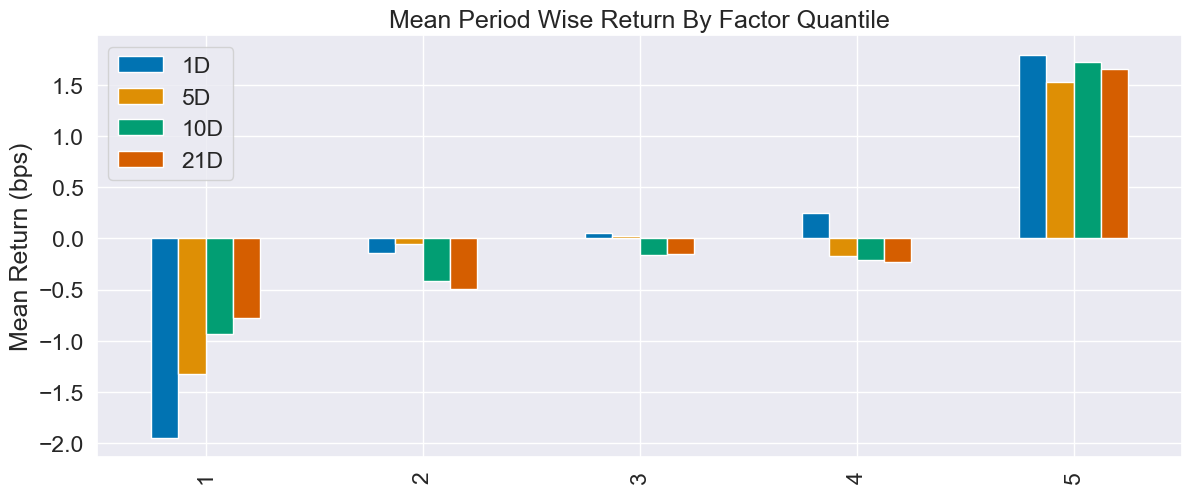

In [106]:
create_summary_tear_sheet(factor_data)

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.121289,0.023201,-0.003619,0.006547,100296,20.006902
2,-0.022556,0.031124,-0.000310,0.005970,100247,19.997128
3,-0.017814,0.038860,0.001305,0.006268,100221,19.991941
4,-0.015327,0.048281,0.002870,0.006750,100247,19.997128
5,-0.013268,0.095294,0.005995,0.008496,100296,20.006902


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.063,0.040,0.036,0.026
beta,0.006,0.041,0.061,0.121
Mean Period Wise Return Top Quantile (bps),1.795,1.532,1.722,1.650
Mean Period Wise Return Bottom Quantile (bps),-1.950,-1.328,-0.935,-0.779
Mean Period Wise Spread (bps),3.745,2.856,2.647,2.418


<Figure size 640x480 with 0 Axes>

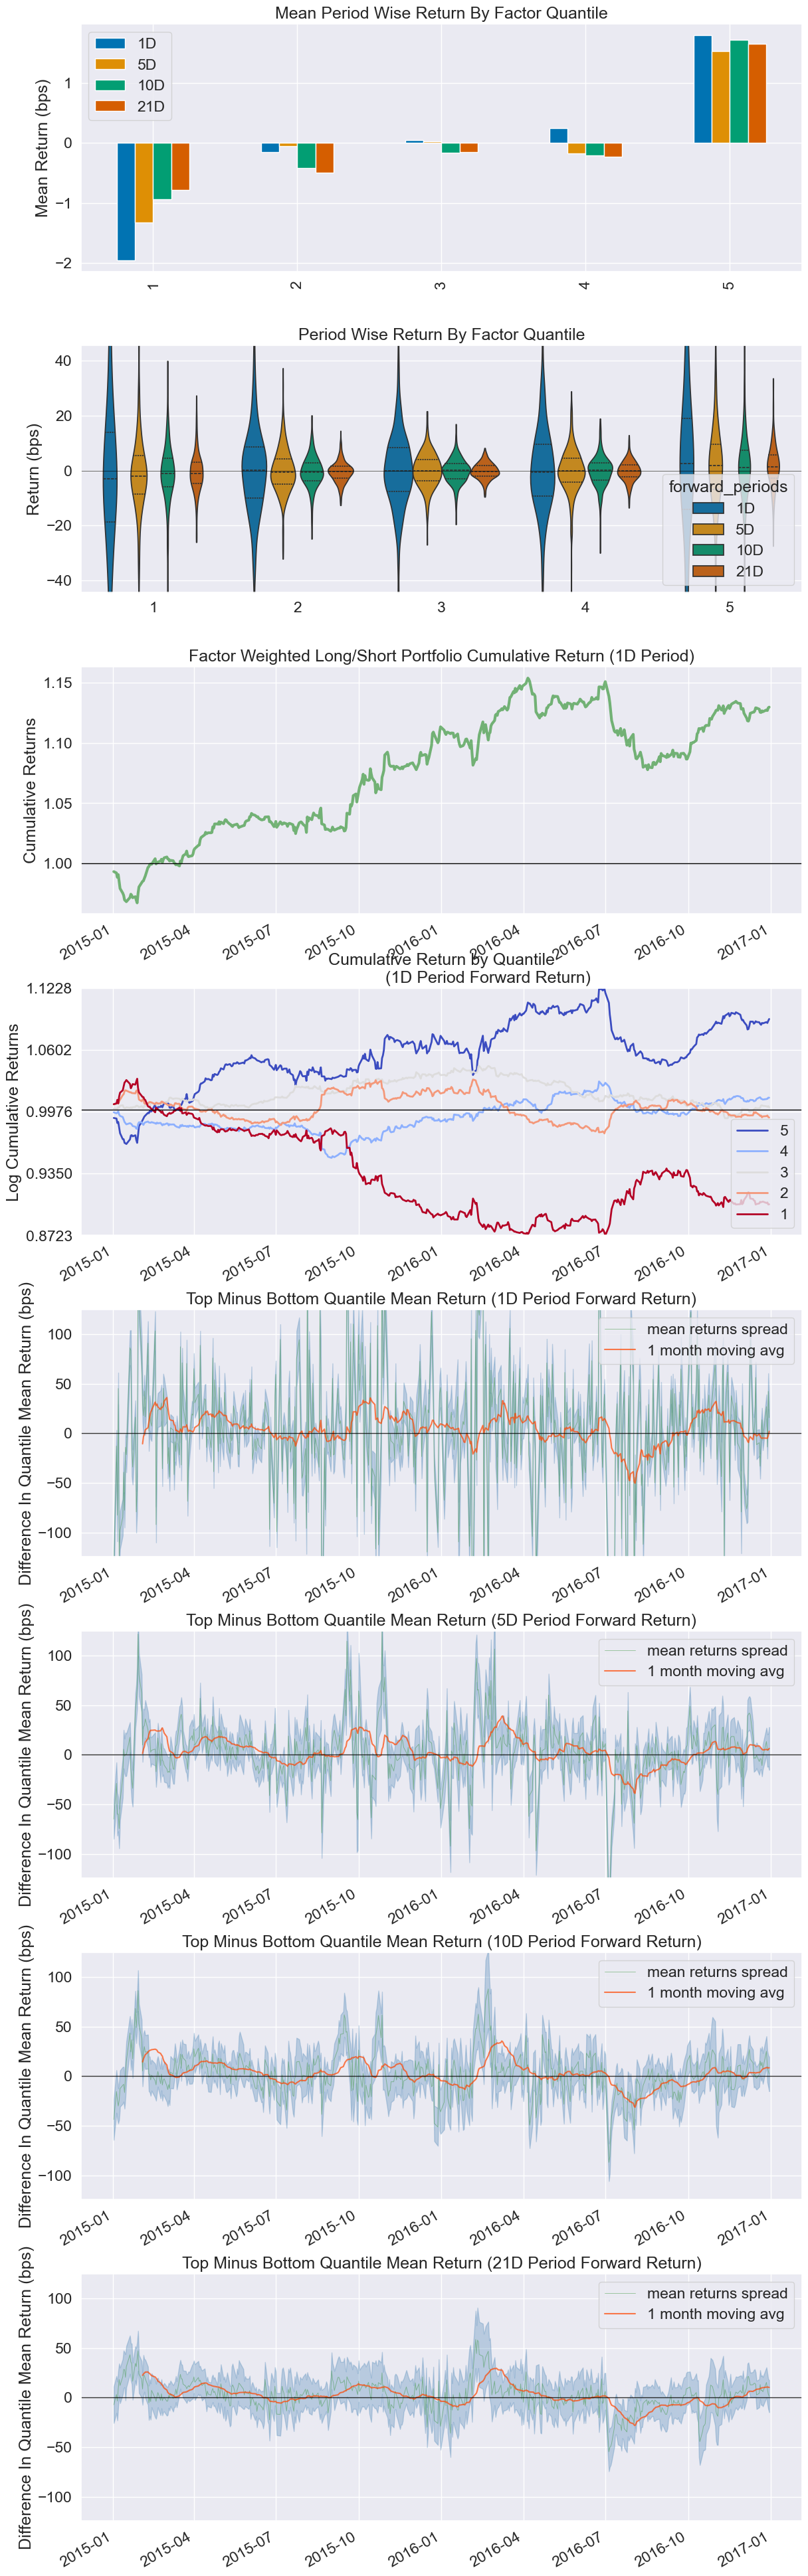

Information Analysis


,1D,5D,10D,21D
IC Mean,0.006,0.009,0.012,0.021
IC Std.,0.124,0.134,0.133,0.133
Risk-Adjusted IC,0.049,0.065,0.089,0.157
t-stat(IC),1.103,1.470,1.988,3.517
p-value(IC),0.270,0.142,0.047,0.000
IC Skew,-0.389,-0.460,-0.128,-0.207
IC Kurtosis,1.608,3.041,1.596,1.114


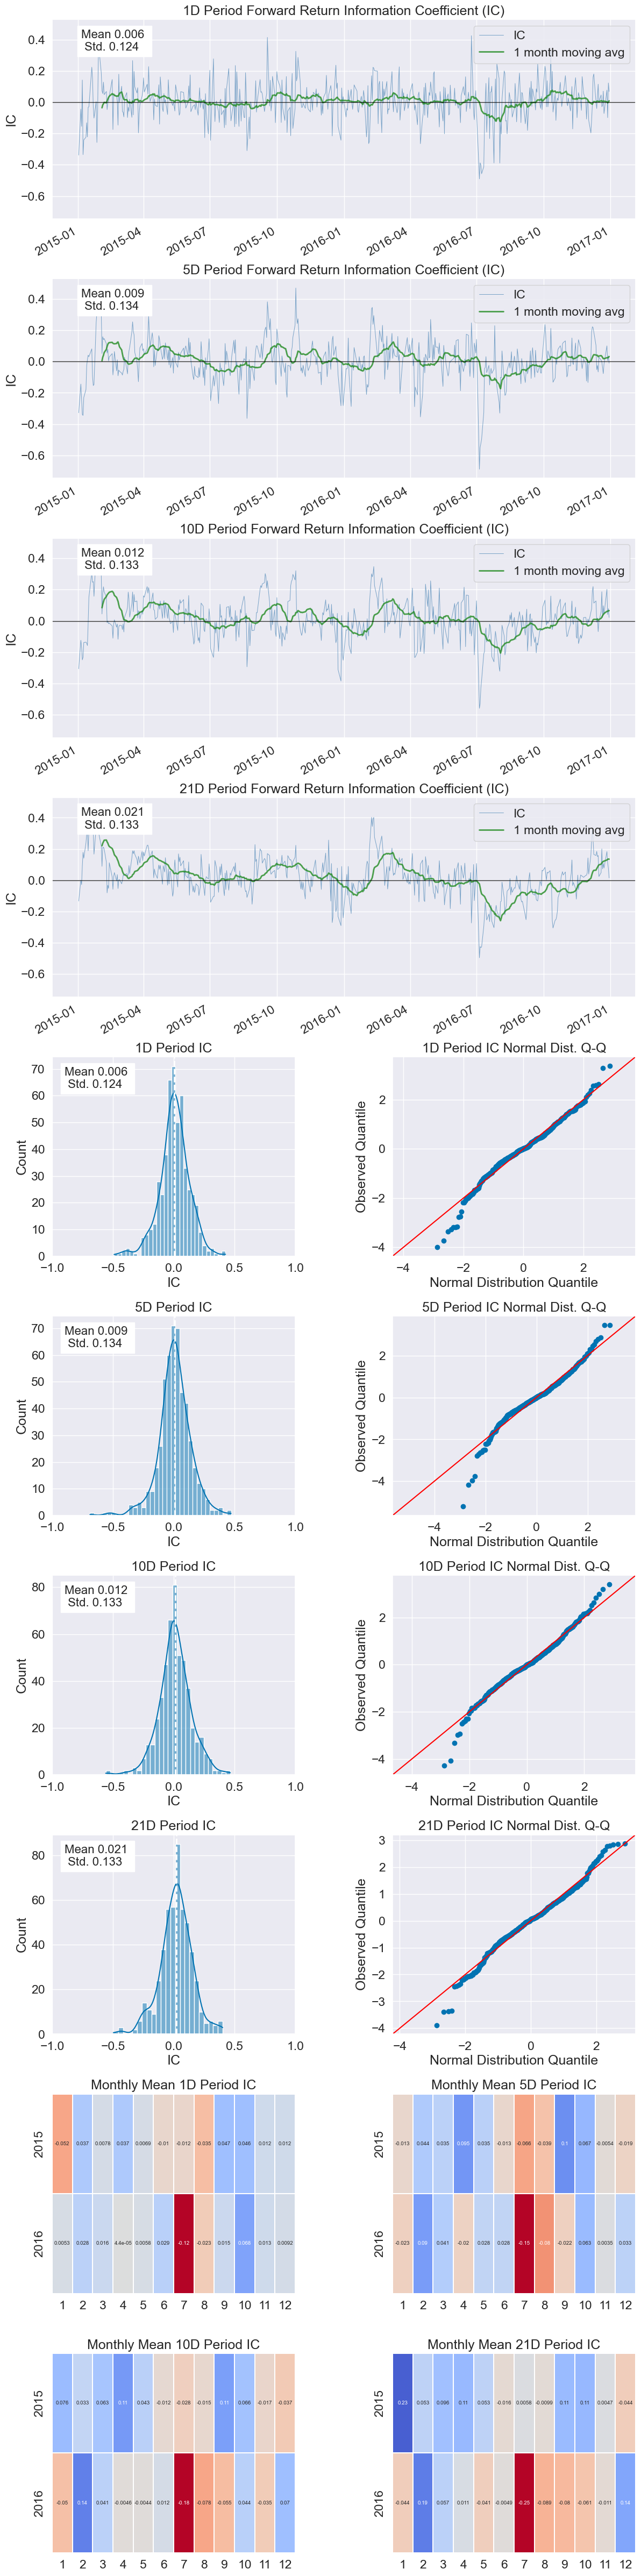

Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.524,0.623,0.683,0.731
Quantile 2 Mean Turnover,0.710,0.749,0.771,0.788
Quantile 3 Mean Turnover,0.737,0.765,0.778,0.788
Quantile 4 Mean Turnover,0.713,0.753,0.770,0.786
Quantile 5 Mean Turnover,0.533,0.632,0.702,0.762


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.491,0.318,0.193,0.085


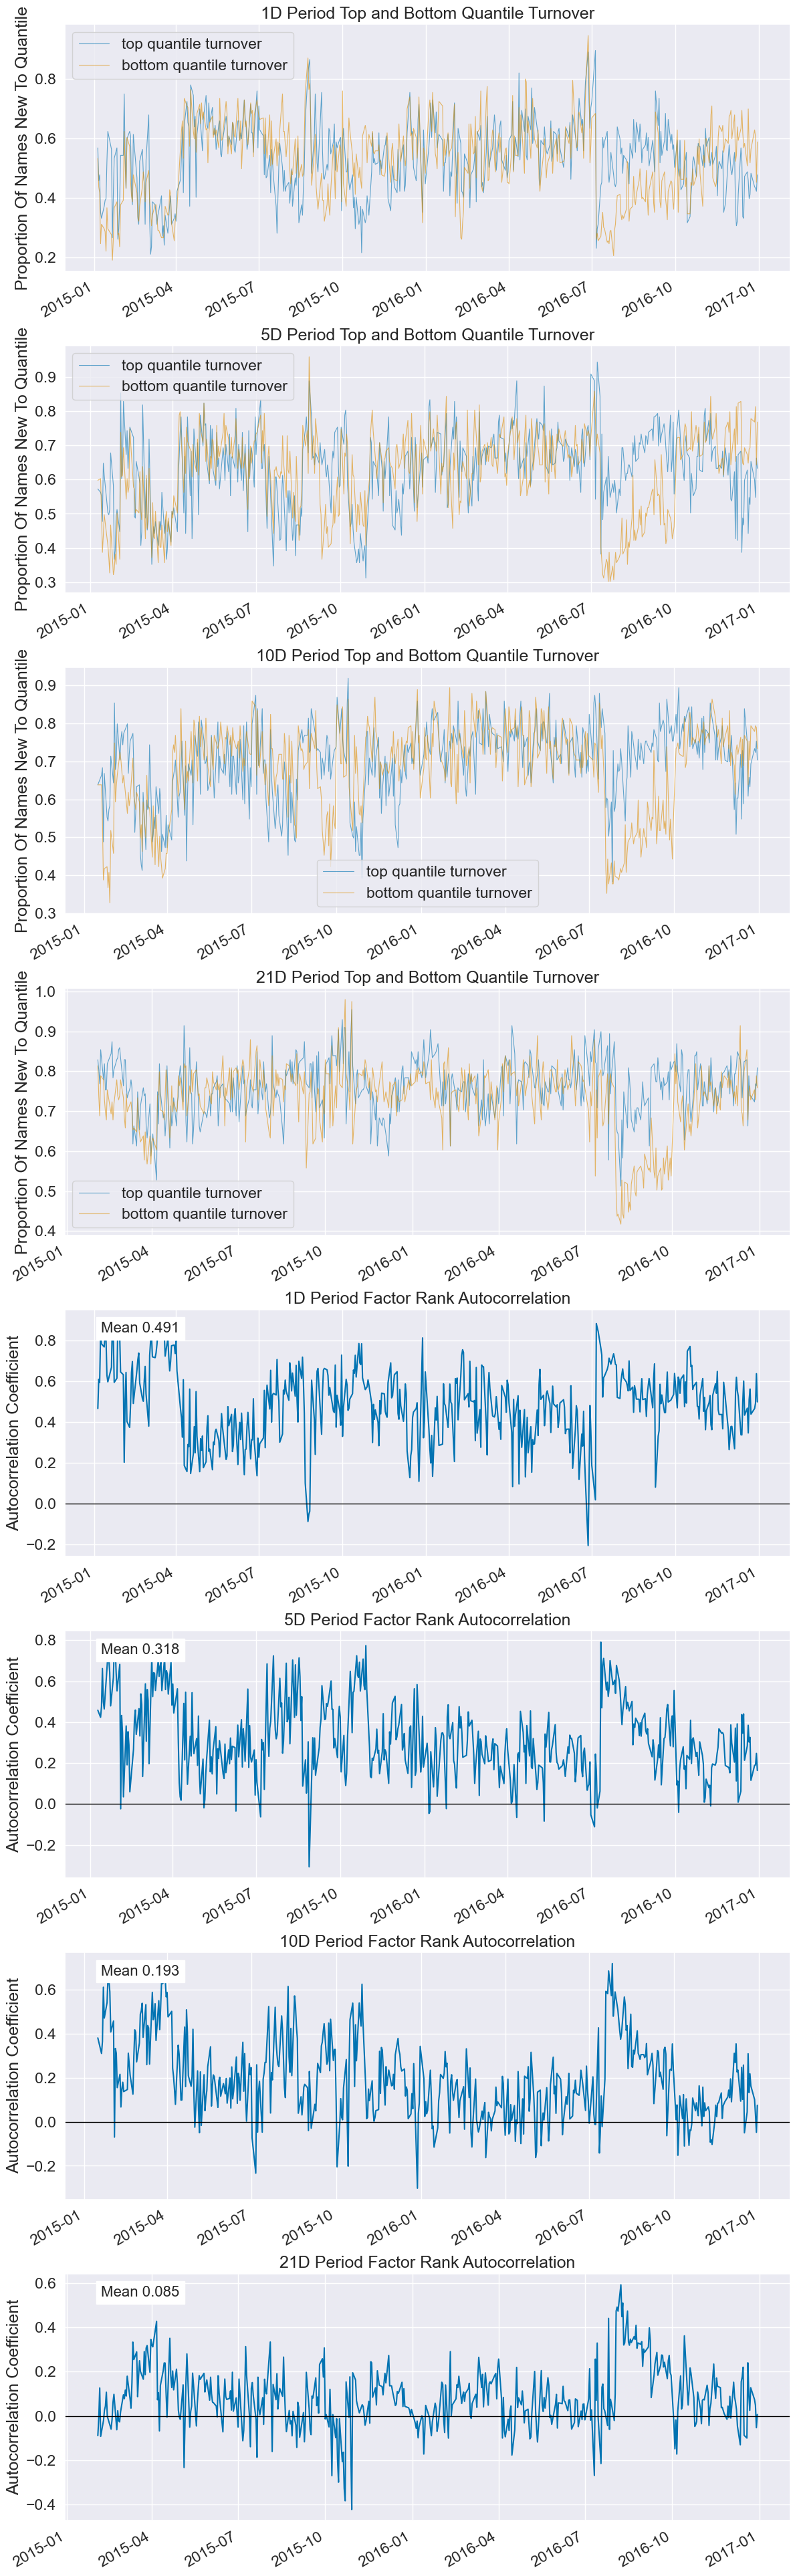

In [107]:
create_full_tear_sheet(factor_data)